<a href="https://colab.research.google.com/github/nashranoor98/credit-card-fraud-detection/blob/main/CaseStudy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Loading and Studying Dataset

In [7]:
import pandas as pd

# IEEE-CIS dataset
transaction = pd.read_csv("data/train_transaction.csv")
identity = pd.read_csv("data/train_identity.csv")

# Use all fraud records and a reproducible sample of legitimate records
fraud = transaction[transaction["isFraud"] == 1]
normal = transaction[transaction["isFraud"] == 0].sample(
    n=min(50000, (transaction["isFraud"] == 0).sum()), random_state=42
)

work = pd.concat([normal, fraud], ignore_index=True)
df = work.merge(identity, on="TransactionID", how="left")

print("Transaction data shape:", transaction.shape)
print("Identity data shape:", identity.shape)
print("Merged working sample shape:", df.shape)

Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)
Merged working sample shape: (70663, 83)


In [8]:
print(df["isFraud"].value_counts())
print(df.shape)

isFraud
0    50000
1    20663
Name: count, dtype: int64
(70663, 83)


In [9]:
print(df.head())
print(df.isnull().sum().head(20))

2. Splitting Dataset

In [10]:
from sklearn.model_selection import train_test_split

numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
numeric_columns.remove("isFraud")

X = df[numeric_columns]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# checking for class distribution
print("Normal Cases: ", sum(y_train == 0))
print("Fraud Cases: ", sum(y_train == 1))

Normal Cases:  40000
Fraud Cases:  16530


3. Applying SMOTE

In [19]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
print("Normal cases: ", sum(y_train_smote == 0))
print("Fraud cases: ", sum(y_train_smote == 1))

Normal cases:  40000
Fraud cases:  40000


4. Training XGBoost and checking Feature Importance


In [20]:
import xgboost as xgb
import matplotlib.pyplot as plt

model = xgb.XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=2
)

model.fit(X_train_smote, y_train_smote)

XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.08, ...)

C12    0.145749
C8     0.126019
C5     0.051107
V10    0.044161
C14    0.036073
C11    0.035741
C2     0.033748
D5     0.032961
D3     0.028285
C4     0.025163
dtype: float32


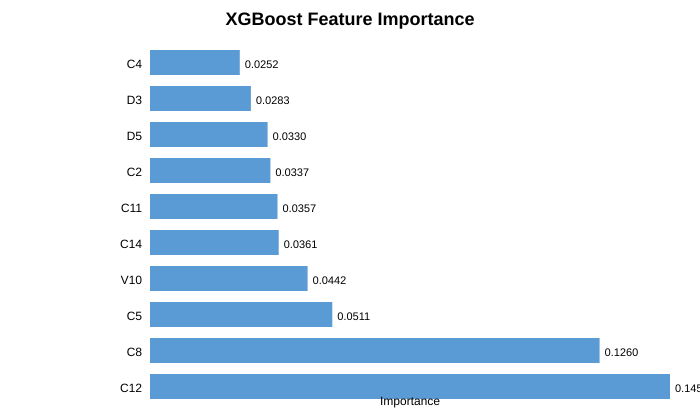

In [22]:
feature_importance = pd.Series(
    model.feature_importances_, index=numeric_columns
).sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(20).plot(kind="bar", figsize=(12, 6))
plt.title("XGB Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

5. Prediction

In [28]:
probabilities = model.predict_proba(X_test)[:, 1]

custom_threshold = 0.40
y_pred = (probabilities >= custom_threshold).astype(int)

6. Evaluating Model

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))

Confusion Matrix
[[9017  983]
 [ 952 3181]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     10000
           1       0.76      0.77      0.77      4133

    accuracy                           0.86     14133
   macro avg       0.83      0.84      0.83     14133
weighted avg       0.86      0.86      0.86     14133


ROC-AUC Score: 0.9117
Threshold: 0.4
Precision: 0.7639
Recall: 0.7697
F1-Score: 0.7668


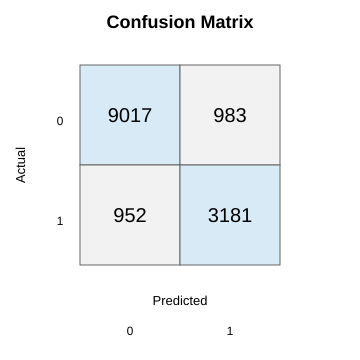

In [30]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

roc_auc = roc_auc_score(y_test, probabilities)
print("ROC-AUC Score:", round(roc_auc, 4))
print("Threshold:", custom_threshold)
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-Score:", round(f1_score(y_test, y_pred), 4))